In [47]:
import numpy as np

In [48]:
from softisoics import mesh_generating, profiles, sampling, utils
from softisoics.constants import G
from softisoics.ICs_writer import ICsWriter

In [49]:
import importlib

importlib.reload(mesh_generating)
importlib.reload(profiles)
importlib.reload(sampling)
importlib.reload(utils)

<module 'softisoics.utils' from '/Users/vinhtran/Data/Research/Mark/SoftIsoICs/SoftIsoICs/src/softisoics/utils.py'>

In [50]:
import warnings

from scipy.integrate import IntegrationWarning

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.simplefilter("ignore", category=IntegrationWarning)

In [51]:
import matplotlib as mpl
from matplotlib import pyplot as plt

# define matplotlib style
plt.style.use("classic")
mpl.rc("xtick", labelsize=23)
mpl.rc("ytick", labelsize=23)
mpl.rc("xtick.major", size=15, width=2)
mpl.rc("xtick.minor", size=8, width=2, visible=True)
mpl.rc("ytick.major", size=15, width=2)
mpl.rc("ytick.minor", size=8, width=2, visible=True)
mpl.rc("lines", linewidth=3, markersize=20)
mpl.rc("axes", linewidth=2, labelsize=30, labelpad=2.5)
mpl.rc("legend", fontsize=25, loc="best", frameon=False, numpoints=1)

mpl.rc("font", family="STIXGeneral")
mpl.rc("mathtext", fontset="stix")

In [52]:
class NFWProfile(profiles.CollisionlessSingleProfile):
    def __init__(self, c=10, **kwargs):
        self.c = c
        super().__init__(**kwargs, halo_edge=c)

    def _nfw_density(self, r):
        return 1 / r / (1 + r) ** 2

    def _decay_density(self, r):
        eps = 1 - (1 + 3 * self.c) / (1 + self.c)
        return (
            1
            / (self.c * (1 + self.c) ** 2)
            * (r / self.c) ** eps
            * np.exp(-(r / self.c - 1))
        )

    def _get_rho_bins(self, r_bins):
        return np.where(
            r_bins < self.c, self._nfw_density(r_bins), self._decay_density(r_bins)
        )

In [53]:
class HernquistProfile(profiles.CollisionalSingleProfile):
    def __init__(self, M, a, **kwargs):
        self.M = M
        self.a = a
        super().__init__(**kwargs)

    def _get_rho_bins(self, r_bins):
        return self.M / (2 * np.pi) * self.a / r_bins / (r_bins + self.a) ** 3

In [54]:
nfw_profile = NFWProfile(
    c=8.28,
    r_bin_min=1e-5,
    r_bin_max=1e3,
    N_bins=10000,
    # epsilon=0.1,
)

In [55]:
hernquist_profile = HernquistProfile(
    M=nfw_profile.mass_bins[-1] * 0.01,
    a=0.25,
    r_bin_min=nfw_profile._r_bin_min,
    r_bin_max=nfw_profile._r_bin_max,
    N_bins=nfw_profile._N_bins,
    # epsilon=0.1,
)

In [56]:
total_phi_bins = nfw_profile.conv_phi_bins + hernquist_profile.conv_phi_bins

nfw_profile.get_potential_dependent_profiles(total_phi_bins=total_phi_bins)
hernquist_profile.get_potential_dependent_profiles(
    total_phi_bins=total_phi_bins, gamma=5 / 3
)

Eddington's inversion: 100%|██████████| 9999/9999 [00:22<00:00, 441.18it/s] 


In [57]:
reconstructed_rho_bins = nfw_profile.reconstruct_density(
    total_phi_bins=nfw_profile.total_phi_bins,
    eps_bins=nfw_profile.eps_bins,
    f_eps_bins=nfw_profile.f_eps_bins,
)

Reconstructing densities: 100%|██████████| 10000/10000 [00:14<00:00, 698.83it/s]


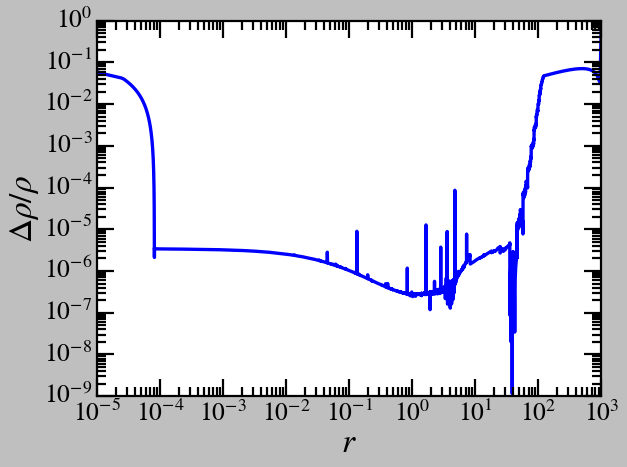

In [58]:
plt.plot(nfw_profile.r_bins, np.abs(1 - reconstructed_rho_bins / nfw_profile.rho_bins))

plt.xlabel(r"$r$")
plt.ylabel(r"$\Delta \rho / \rho$")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.show()

In [59]:
N_200 = 1e6

N_part = utils.get_N_part_from_N_200(
    N_200=N_200,
    r200=nfw_profile.c,
    r_sample_max=5 * nfw_profile.c,
    r_bins=nfw_profile.r_bins,
    mass_bins=nfw_profile.mass_bins,
)

In [60]:
particle_sampler = sampling.SampleParticles(
    r_bins=nfw_profile.r_bins,
    rho_bins=nfw_profile.rho_bins,
    mass_bins=nfw_profile.mass_bins,
    total_phi_bins=nfw_profile.total_phi_bins,
    eps_bins=nfw_profile.eps_bins,
    f_eps_bins=nfw_profile.f_eps_bins,
    r_sample_min=1e-4,
    r_sample_max=5 * nfw_profile.c,
    N_part=N_part,
    # kappa_L=0.5,
)

Sampling velocities: 100%|██████████| 9999/9999 [00:13<00:00, 768.42it/s] 


In [61]:
halo = utils.Halo()
halo.input_from_particles(
    part_coords=particle_sampler.part_coords,
    part_velocs=particle_sampler.part_velocs,
    part_mass=particle_sampler.part_mass,
)

sampled_L_x, sampled_L_y, sampled_L_z = halo.get_angular_momenta()

sigma_L = np.sqrt(particle_sampler.part_mass) * nfw_profile.L_err_scaler

print(f"L_max / sigma_L: {(nfw_profile.L_max / sigma_L):.2e}")  # noqa: T201
print(f"L_x / sigma_L: {(sampled_L_x / sigma_L):.2e}")  # noqa: T201
print(f"L_y / sigma_L: {(sampled_L_y / sigma_L):.2e}")  # noqa: T201
print(f"L_z / sigma_L: {(sampled_L_z / sigma_L):.2e}")  # noqa: T201

(
    sampled_r_bins,
    sampled_rho_bins,
    sampled_rho_bins_err,
    sampled_sigma_r_bins,
    sampled_sigma_r_bins_err,
) = halo.get_profiles()

L_max / sigma_L: 8.58e+02
L_x / sigma_L: 4.59e-02
L_y / sigma_L: -3.94e-01
L_z / sigma_L: 2.67e-01


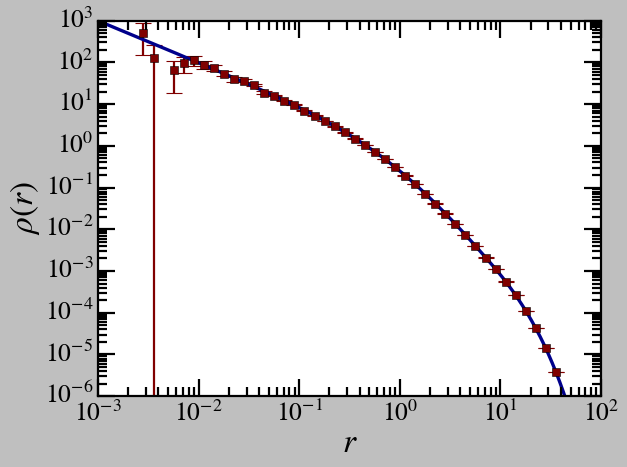

In [62]:
plt.errorbar(
    sampled_r_bins,
    sampled_rho_bins,
    yerr=sampled_rho_bins_err,
    fmt=" s",
    color="maroon",
    markersize=7.5,
    elinewidth=2,
    capsize=7.5,
    capthick=1,
)

plt.plot(nfw_profile.r_bins, nfw_profile.rho_bins, color="darkblue")

plt.xlim(1e-3, 1e2)
plt.ylim(1e-6, 1e3)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$\rho (r)$")

plt.tight_layout()
plt.show()

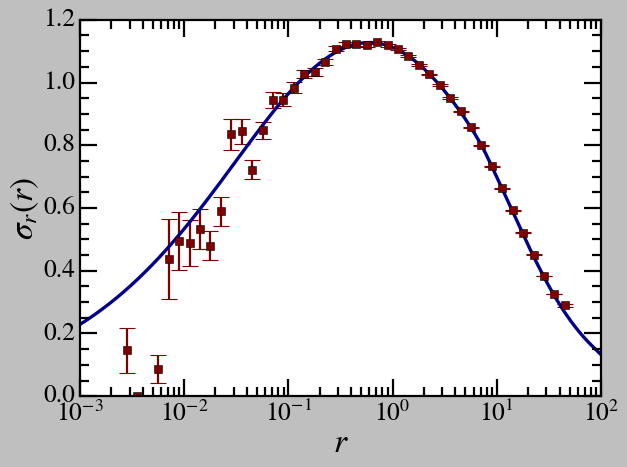

In [63]:
plt.errorbar(
    sampled_r_bins,
    sampled_sigma_r_bins,
    yerr=sampled_sigma_r_bins_err,
    fmt=" s",
    color="maroon",
    markersize=7.5,
    elinewidth=2,
    capsize=7.5,
    capthick=1,
)

plt.plot(nfw_profile.r_bins, nfw_profile.sigma_r_bins, color="darkblue")

plt.xlim(1e-3, 1e2)

plt.xscale("log")
# plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$\sigma_r (r)$")

plt.tight_layout()
plt.show()

In [64]:
N_cell = int(1e5)

mesh_generator = mesh_generating.GenerateMesh(
    r_bins=hernquist_profile.r_bins,
    rho_bins=hernquist_profile.rho_bins,
    mass_bins=hernquist_profile.mass_bins,
    internal_energy_bins=hernquist_profile.internal_energy_bins,
    r_sample_max=5 * nfw_profile.c,
    N_cell=N_cell,
)

In [65]:
rs = 25.48
rhos = 3.60e06

unit_length = rs
unit_mass = rhos * rs**3 / 1e10
unit_velocity = np.sqrt(G * unit_mass / unit_length)
unit_energy = unit_velocity**2

In [66]:
part_coords = particle_sampler.part_coords * unit_length
part_velocs = particle_sampler.part_velocs * unit_velocity
part_masses = np.full(N_part, particle_sampler.part_mass * unit_mass)
part_ids = np.arange(1, particle_sampler._N_part + 1)

In [67]:
mesh_coords = mesh_generator.mesh_coords * unit_length
mesh_masses = mesh_generator.mesh_masses * unit_mass
mesh_velocs = mesh_generator.mesh_velocs * unit_velocity
mesh_internal_energies = mesh_generator.mesh_internal_energies * unit_energy
mesh_ids = np.arange(1, mesh_generator._N_cell + 1)

In [68]:
dm_info = {
    "part_coords": part_coords,
    "part_velocs": part_velocs,
    "part_masses": part_masses,
    "part_ids": part_ids,
}

gas_info = {
    "cell_coords": mesh_coords,
    "cell_masses": mesh_masses,
    "cell_velocs": mesh_velocs,
    "cell_internal_energies": mesh_internal_energies,
    "cell_ids": mesh_ids,
}

In [69]:
writer = ICsWriter(
    dm_info=dm_info,
    gas_info=gas_info,
)

# writer.write(filename="../../ICs/ICs_gas_bulge.hdf5")